In [1]:
pip install dice_ml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 86.8 MB/s eta 0:00:00


In [3]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


Total HRS High Risk Patients: 61
After CatBoost filter: 33


 88%|████████▊ | 29/33 [08:17<02:31, 37.90s/it]

No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec


 97%|█████████▋| 32/33 [08:18<00:13, 13.18s/it]

No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec


100%|██████████| 33/33 [08:18<00:00, 15.12s/it]


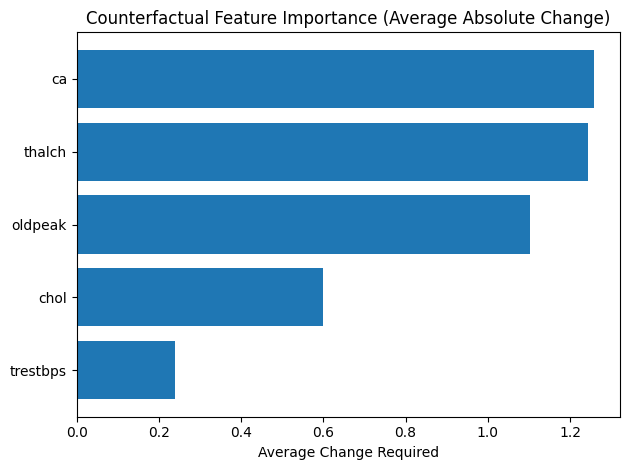


NARRATIVE COUNTERFACTUAL EXPLANATIONS WITH AMOUNT
Patient 1 had a predicted heart disease risk of 0.91. The risk could be reduced to 0.65 if trestbps is decreased by 5.10, oldpeak is decreased by 0.38, ca is decreased by 1.42. This is an AI-generated suggestion and not real medical advice. Consult a doctor.
Patient 1 had a predicted heart disease risk of 0.91. The risk could be reduced to 0.46 if oldpeak is decreased by 1.62, thalch is increased by 0.55, ca is decreased by 0.88. This is an AI-generated suggestion and not real medical advice. Consult a doctor.
Patient 1 had a predicted heart disease risk of 0.91. The risk could be reduced to 0.49 if oldpeak is decreased by 2.65, thalch is increased by 1.78, ca is decreased by 1.18. This is an AI-generated suggestion and not real medical advice. Consult a doctor.
Patient 2 had a predicted heart disease risk of 0.97. The risk could be reduced to 0.57 if thalch is increased by 3.25, chol is increased by 2.02, ca is decreased by 1.85. This

In [16]:
# =========================================
# ISHITA – FULL COUNTERFACTUAL PIPELINE
# RF for Counterfactuals
# CatBoost for Risk Prediction
# HRS for High Risk Selection
# =========================================

import pandas as pd
import numpy as np
import joblib
import dice_ml
from dice_ml import Dice
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# =========================================
# 1. LOAD DATA
# =========================================
df = pd.read_csv("cleaned_train.csv")

TARGET = 'target'
X = df.drop(columns=[TARGET])
y = df[TARGET]

# =========================================
# 2. TRAIN RANDOM FOREST (FOR DICE)
# =========================================
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X, y)

joblib.dump(rf, "random_forest_model.pkl")

# =========================================
# 3. LOAD CATBOOST MODEL (FOR RISK)
# =========================================
catboost_model = joblib.load("catboost_model.pkl")

# Probability function
def predict_proba(model, df):
    return model.predict_proba(df)[:,1]

# =========================================
# 4. LOAD HRS RISK CATEGORIES
# =========================================
hrs = pd.read_csv("hrs_risk_categories.csv")
hrs.columns = hrs.columns.str.lower()

high_risk_ids = hrs[hrs['risk_class'].str.lower() == 'high'].index

df = df.reset_index(drop=True)
high_risk_df = df.iloc[high_risk_ids]

print("Total HRS High Risk Patients:", len(high_risk_df))

# CatBoost filter
preds = (predict_proba(catboost_model, high_risk_df[X.columns]) > 0.5).astype(int)
high_risk_df = high_risk_df[preds == 1]

print("After CatBoost filter:", len(high_risk_df))

# =========================================
# 5. DiCE SETUP
# =========================================
data_dice = dice_ml.Data(
    dataframe=df,
    continuous_features=list(X.columns),
    outcome_name=TARGET
)

model_dice = dice_ml.Model(model=rf, backend="sklearn")
dice = Dice(data_dice, model_dice)

# =========================================
# 6. MEDICAL CONSTRAINTS
# =========================================
# =========================================
# 6. MEDICAL CONSTRAINTS
# =========================================

features_to_vary = ['trestbps', 'oldpeak', 'thalch', 'chol', 'ca']

immutable_features = ['age', 'sex_Male']

permitted_range = {
    'trestbps': [-1.5, 1.5],
    'oldpeak': [-2, 1],
    'thalch': [-1, 2],
    'chol': [-2, 1.5],
    'ca': [-2, 0]
}

data_dice = dice_ml.Data(
    dataframe=df,
    continuous_features=list(X.columns),
    outcome_name=TARGET,
    immutable_features=immutable_features
)


# =========================================
# 7. GENERATE COUNTERFACTUALS FOR ALL HIGH RISK
# =========================================
query_instances_clean = high_risk_df[X.columns]

cf = dice.generate_counterfactuals(
    query_instances_clean,
    total_CFs=3,
    desired_class=0,
    features_to_vary=features_to_vary,
    permitted_range=permitted_range
)

# =========================================
# 8. COUNTERFACTUAL IMPACT PLOT (CORRECT)
# =========================================
feature_changes = []

for cf_example in cf.cf_examples_list:
    original = cf_example.test_instance_df
    cfs = cf_example.final_cfs_df

    if cfs is None:
        continue

    for i in range(len(cfs)):
        for col in features_to_vary:
            diff = abs(cfs.iloc[i][col] - original.iloc[0][col])
            feature_changes.append({"feature": col, "change": diff})

plot_df = pd.DataFrame(feature_changes)
plot_df = plot_df.groupby("feature")["change"].mean().reset_index()
plot_df = plot_df.sort_values(by="change", ascending=True)

plt.figure()
plt.barh(plot_df["feature"], plot_df["change"])
plt.title("Counterfactual Feature Importance (Average Absolute Change)")
plt.xlabel("Average Change Required")
plt.tight_layout()
plt.savefig("Plot_13_Counterfactual_Impact.png")
plt.show()


# =========================================
# 9. TABLE 11 – COUNTERFACTUAL TABLE (ALL PATIENTS)
# =========================================
tables = []

for idx in range(len(cf.cf_examples_list)):
    cf_example = cf.cf_examples_list[idx]
    original = cf_example.test_instance_df
    cfs = cf_example.final_cfs_df

    if cfs is None:
        continue

    original_prob = predict_proba(catboost_model, original[X.columns])[0]
    original["risk"] = original_prob

    for i in range(len(cfs)):
        cf_prob = predict_proba(catboost_model, cfs.iloc[[i]][X.columns])[0]
        cfs.loc[cfs.index[i], "risk"] = cf_prob

    table = pd.concat([original, cfs])
    table["patient"] = idx+1
    tables.append(table)

counterfactual_table = pd.concat(tables)
counterfactual_table.to_csv("Table_11_Counterfactual_Table_ALL.csv", index=False)

# =========================================
# 10. TABLE 13 – COUNTERFACTUAL SUMMARY
# =========================================
summary_rows = []

for idx in range(len(cf.cf_examples_list)):
    cf_example = cf.cf_examples_list[idx]
    original = cf_example.test_instance_df
    cfs = cf_example.final_cfs_df

    if cfs is None:
        continue

    original_prob = predict_proba(catboost_model, original[X.columns])[0]

    for j in range(len(cfs)):
        cf_instance = cfs.iloc[[j]]
        cf_prob = predict_proba(catboost_model, cf_instance[X.columns])[0]

        risk_reduction = ((original_prob - cf_prob) / original_prob) * 100

        changes = []
        for col in features_to_vary:
            original_val = original.iloc[0][col]
            new_val = cf_instance.iloc[0][col]
            if abs(original_val - new_val) > 0.1:
                changes.append(col)

        summary_rows.append({
            "Patient": idx+1,
            "Changed Features": ", ".join(changes),
            "Original Risk": round(original_prob,3),
            "New Risk": round(cf_prob,3),
            "% Risk Reduction": round(risk_reduction,2)
        })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("Table_13_Counterfactual_Summary_ALL.csv", index=False)

# =========================================
# 11. CLINICAL EXPLANATIONS
# =========================================
print("\nNARRATIVE COUNTERFACTUAL EXPLANATIONS WITH AMOUNT")

for idx in range(len(cf.cf_examples_list)):
    cf_example = cf.cf_examples_list[idx]
    original = cf_example.test_instance_df
    cfs = cf_example.final_cfs_df

    if cfs is None:
        continue

    original_prob = predict_proba(catboost_model, original[X.columns])[0]

    for j in range(len(cfs)):
        cf_instance = cfs.iloc[[j]]
        cf_prob = predict_proba(catboost_model, cf_instance[X.columns])[0]

        narrative = f"Patient {idx+1} had a predicted heart disease risk of {original_prob:.2f}. "
        narrative += "The risk could be reduced to "
        narrative += f"{cf_prob:.2f} if "

        changes_text = []
        for col in features_to_vary:
            original_val = original.iloc[0][col]
            new_val = cf_instance.iloc[0][col]
            diff = new_val - original_val

            if abs(diff) > 0.1:
                if diff > 0:
                    changes_text.append(f"{col} is increased by {abs(diff):.2f}")
                else:
                    changes_text.append(f"{col} is decreased by {abs(diff):.2f}")

        narrative += ", ".join(changes_text)
        narrative += ". This is an AI-generated suggestion and not real medical advice. Consult a doctor."

        print(narrative)

